Original Dataset Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Gender: Male
Roll Number: 150096724005
Study Hours Threshold: 1
More than 150 rows found.
Both conditions retained.

Final Personalized Dataset Shape: (456, 16)

========== MISSING VALUES ==========
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         34
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

========== DUPLICATES ==========
Duplicate rows: 0

========== STATISTICAL SUMMARY ==========


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000
mean,20.561404,3.651754,2.500000,1.817544,83.886623,6.430044,3.182018,5.436404,70.848904
std,2.388747,1.356708,1.183495,1.068654,9.523000,1.250704,1.999941,2.813685,15.956698
min,17.000000,1.000000,0.000000,0.000000,59.700000,3.300000,0.000000,1.000000,28.000000
25%,18.000000,2.700000,1.700000,1.000000,77.300000,5.500000,1.000000,3.000000,60.250000
50%,21.000000,3.500000,2.500000,1.800000,83.950000,6.500000,3.000000,5.000000,70.900000
75%,23.000000,4.500000,3.300000,2.600000,90.825000,7.300000,5.000000,8.000000,81.950000
max,24.000000,8.300000,7.200000,4.900000,100.000000,10.000000,6.000000,10.000000,100.000000



study_hours_per_day
Q1: 2.7
Q3: 4.5
IQR: 1.7999999999999998
Lower Bound: 4.440892098500626e-16
Upper Bound: 7.199999999999999
Number of Outliers: 4

exam_score
Q1: 60.25
Q3: 81.95
IQR: 21.700000000000003
Lower Bound: 27.699999999999996
Upper Bound: 114.5
Number of Outliers: 0

Missing values after cleaning:
0


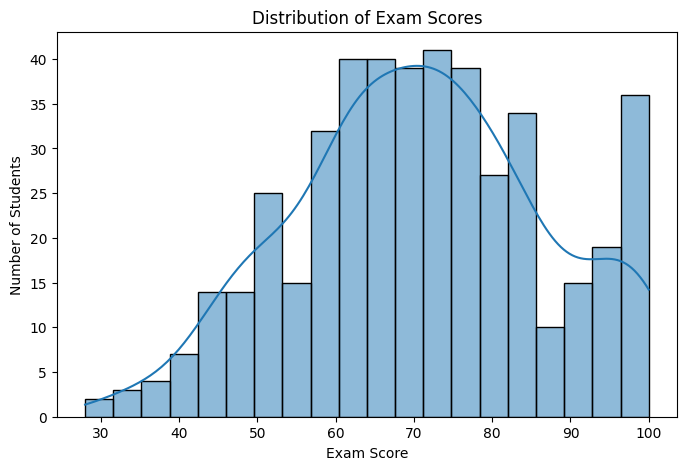

Insight:
The exam scores are spread across a wide range, with most students
having scores around the middle-to-high range.


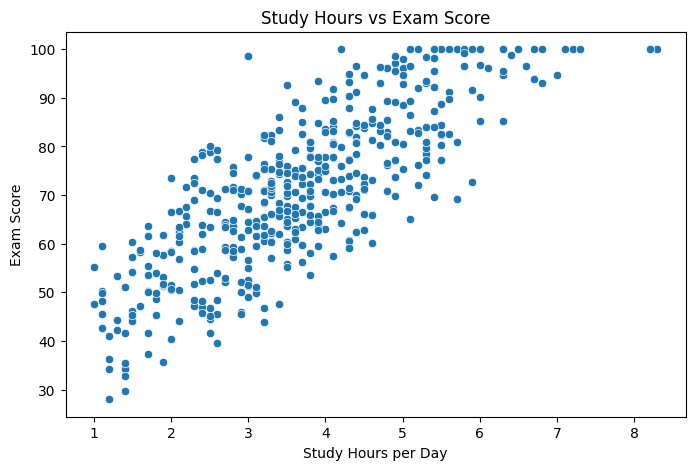

Insight:
Study hours and exam score show a positive relationship (correlation = 0.80).
Students who study more generally tend to achieve higher scores.


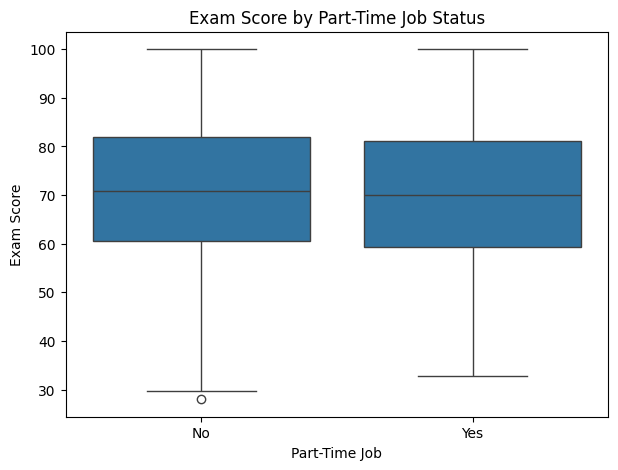

Insight:
part_time_job
No     71.024507
Yes    70.231683
Name: exam_score, dtype: float64
The boxplot shows how exam scores differ between students with and without a part-time job.


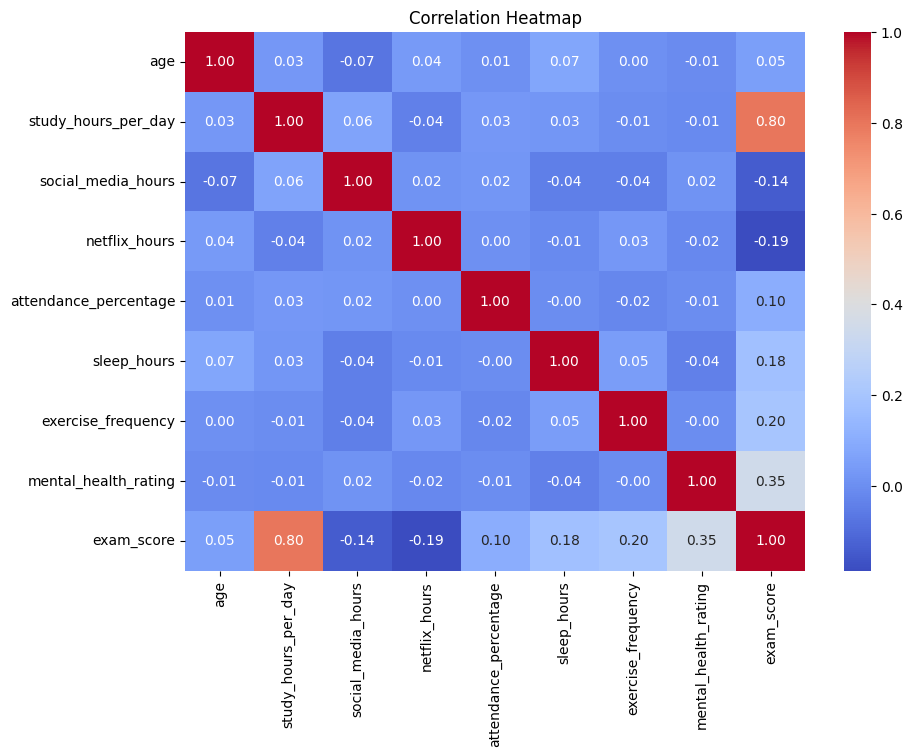

Insight:
Study hours and attendance show a positive relationship with exam score, while some lifestyle variables have weaker relationships.


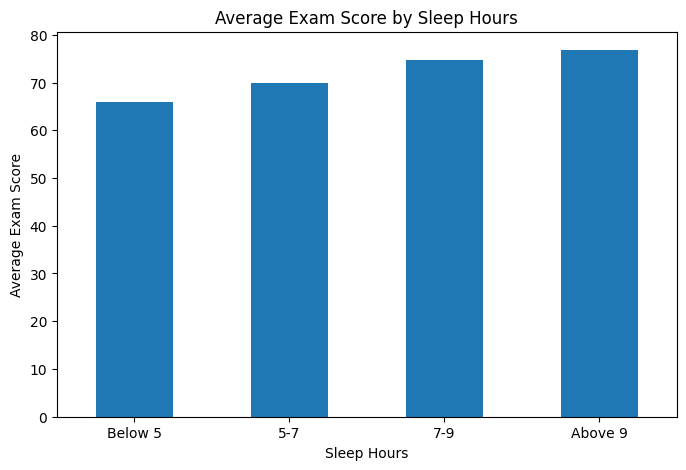

Insight:
Average exam scores vary across sleep groups, showing that sleep may have some relationship with academic performance.
Training samples: 364
Testing samples: 92

========== MODEL RESULTS ==========
R² Score: 0.898
RMSE: 5.100

PASS CONDITION ACHIEVED!
Test R² is greater than or equal to 0.70.


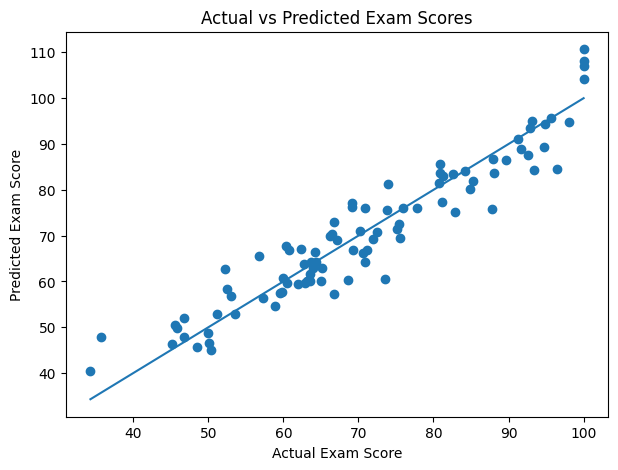


========== SIMPLE MODEL RESULTS ==========
R² Score: 0.794
RMSE: 7.233

========== MODEL COMPARISON ==========
Simple Model  -> R²: 0.794, RMSE: 7.233
Full Model    -> R²: 0.898, RMSE: 5.100

========== FEATURE COEFFICIENTS ==========


,Feature,Coefficient
0,study_hours_per_day,9.409976
2,sleep_hours,2.212687
3,mental_health_rating,1.975562
1,attendance_percentage,0.162192



========== FINAL SUMMARY ==========

The personalized dataset contains 456 male students.

The personalization rule required study hours of at least
1 hour per day.

The dataset was checked for missing values, duplicate rows,
and outliers. Missing categorical values were handled using
the mode.

Five main visualizations were created to understand the
relationship between study habits and exam performance.

A Linear Regression model was trained using an 80/20
train-test split.

Final Model R²: 0.898
Final Model RMSE: 5.100

The model meets the required
R² pass condition of 0.70.

Overall, study hours and attendance appear to be important
factors associated with exam performance in this subset.



In [7]:
# ============================================================
# MACHINE LEARNING FUNDAMENTALS
# Assignment 4: Student Exam Score Prediction
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("student_habits_performance.csv")

print("Original Dataset Shape:", df.shape)
display(df.head())


# ============================================================
# 3. PERSONALIZE THE DATASET
# ============================================================

gender = "Male"
roll_number = 150096724005

# Calculate study hour condition
study_threshold = (roll_number % 5) + 1

print("Gender:", gender)
print("Roll Number:", roll_number)
print("Study Hours Threshold:", study_threshold)

# Apply gender filter
personalized_df = df[
    df["gender"].str.lower() == gender.lower()
].copy()

# Apply study-hours condition
filtered_df = personalized_df[
    personalized_df["study_hours_per_day"] >= study_threshold
].copy()

# If fewer than 150 rows, remove study-hours condition
if len(filtered_df) < 150:
    filtered_df = personalized_df.copy()
    print("Less than 150 rows found.")
    print("Study-hours condition removed.")
else:
    print("More than 150 rows found.")
    print("Both conditions retained.")

print("\nFinal Personalized Dataset Shape:", filtered_df.shape)


# ============================================================
# 4. BASIC EDA
# ============================================================

print("\n========== MISSING VALUES ==========")
print(filtered_df.isnull().sum())

print("\n========== DUPLICATES ==========")
print("Duplicate rows:", filtered_df.duplicated().sum())

print("\n========== STATISTICAL SUMMARY ==========")
display(filtered_df.describe())


# ============================================================
# 5. OUTLIER CHECK
# ============================================================

def check_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))

    return outliers


study_outliers = check_outliers(
    filtered_df,
    "study_hours_per_day"
)

score_outliers = check_outliers(
    filtered_df,
    "exam_score"
)


# ============================================================
# 6. HANDLE MISSING VALUES
# ============================================================

# Fill missing categorical values with mode
for column in filtered_df.select_dtypes(include="object").columns:

    if filtered_df[column].isnull().sum() > 0:
        filtered_df[column] = filtered_df[column].fillna(
            filtered_df[column].mode()[0]
        )

print("\nMissing values after cleaning:")
print(filtered_df.isnull().sum().sum())


# ============================================================
# 7. PLOT 1 - SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    filtered_df["exam_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

print("Insight:")
print("The exam scores are spread across a wide range, with most students")
print("having scores around the middle-to-high range.")


# ============================================================
# 8. PLOT 2 - STUDY HOURS VS EXAM SCORE
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=filtered_df,
    x="study_hours_per_day",
    y="exam_score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")
plt.show()

correlation = filtered_df[
    ["study_hours_per_day", "exam_score"]
].corr().iloc[0, 1]

print("Insight:")
print(
    f"Study hours and exam score show a positive relationship "
    f"(correlation = {correlation:.2f})."
)
print("Students who study more generally tend to achieve higher scores.")


# ============================================================
# 9. PLOT 3 - SCORE BY PART-TIME JOB
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=filtered_df,
    x="part_time_job",
    y="exam_score"
)

plt.title("Exam Score by Part-Time Job Status")
plt.xlabel("Part-Time Job")
plt.ylabel("Exam Score")
plt.show()

print("Insight:")

avg_part_time = filtered_df.groupby(
    "part_time_job"
)["exam_score"].mean()

print(avg_part_time)

print(
    "The boxplot shows how exam scores differ between students "
    "with and without a part-time job."
)


# ============================================================
# 10. PLOT 4 - CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

numeric_columns = filtered_df.select_dtypes(
    include=np.number
).columns

correlation_matrix = filtered_df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

print("Insight:")
print(
    "Study hours and attendance show a positive relationship with exam score, "
    "while some lifestyle variables have weaker relationships."
)


# ============================================================
# 11. PLOT 5 - SLEEP HOURS BUCKET
# ============================================================

# Create sleep-hour groups
filtered_df["sleep_bucket"] = pd.cut(
    filtered_df["sleep_hours"],
    bins=[0, 5, 7, 9, 12],
    labels=[
        "Below 5",
        "5-7",
        "7-9",
        "Above 9"
    ]
)

sleep_average = filtered_df.groupby(
    "sleep_bucket",
    observed=False
)["exam_score"].mean()

plt.figure(figsize=(8, 5))

sleep_average.plot(
    kind="bar"
)

plt.title("Average Exam Score by Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.show()

print("Insight:")
print(
    "Average exam scores vary across sleep groups, showing that sleep "
    "may have some relationship with academic performance."
)


# ============================================================
# 12. PREPARE DATA FOR LINEAR REGRESSION
# ============================================================

# Features used for prediction
features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "mental_health_rating",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "part_time_job",
    "diet_quality",
    "internet_quality",
    "extracurricular_participation",
    "parental_education_level"
]

X = filtered_df[features]
y = filtered_df["exam_score"]


# Identify categorical columns
categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

numeric_columns = X.select_dtypes(
    exclude="object"
).columns.tolist()


# Encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)


# ============================================================
# 13. SPLIT DATA 80/20
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 14. BUILD LINEAR REGRESSION MODEL
# ============================================================

model = Pipeline(
    steps=[
        ("encoding", preprocessor),
        ("regression", LinearRegression())
    ]
)

model.fit(X_train, y_train)


# ============================================================
# 15. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 16. MODEL EVALUATION
# ============================================================

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("\n========== MODEL RESULTS ==========")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")


# ============================================================
# 17. CHECK PASS CONDITION
# ============================================================

if r2 >= 0.70:

    print("\nPASS CONDITION ACHIEVED!")
    print("Test R² is greater than or equal to 0.70.")

else:

    print("\nPASS CONDITION NOT ACHIEVED.")
    print("Further model refinement is required.")


# ============================================================
# 18. ACTUAL VS PREDICTED SCORES
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# ============================================================
# 19. SIMPLE MODEL REFINEMENT
# ============================================================

# A simpler model using the strongest/basic features
simple_features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "mental_health_rating"
]

X_simple = filtered_df[simple_features]
y_simple = filtered_df["exam_score"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(
    X_train_s,
    y_train_s
)

simple_pred = simple_model.predict(X_test_s)

simple_r2 = r2_score(
    y_test_s,
    simple_pred
)

simple_rmse = np.sqrt(
    mean_squared_error(
        y_test_s,
        simple_pred
    )
)

print("\n========== SIMPLE MODEL RESULTS ==========")
print(f"R² Score: {simple_r2:.3f}")
print(f"RMSE: {simple_rmse:.3f}")


# ============================================================
# 20. FINAL MODEL COMPARISON
# ============================================================

print("\n========== MODEL COMPARISON ==========")

print(
    f"Simple Model  -> R²: {simple_r2:.3f}, RMSE: {simple_rmse:.3f}"
)

print(
    f"Full Model    -> R²: {r2:.3f}, RMSE: {rmse:.3f}"
)


# ============================================================
# 21. FEATURE IMPORTANCE / COEFFICIENTS
# ============================================================

# Coefficients of the simple linear regression model

coefficient_df = pd.DataFrame({
    "Feature": simple_features,
    "Coefficient": simple_model.coef_
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n========== FEATURE COEFFICIENTS ==========")
display(coefficient_df)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n========== FINAL SUMMARY ==========")

print(
    f"""
The personalized dataset contains {len(filtered_df)} male students.

The personalization rule required study hours of at least
{study_threshold} hour per day.

The dataset was checked for missing values, duplicate rows,
and outliers. Missing categorical values were handled using
the mode.

Five main visualizations were created to understand the
relationship between study habits and exam performance.

A Linear Regression model was trained using an 80/20
train-test split.

Final Model R²: {r2:.3f}
Final Model RMSE: {rmse:.3f}

The model {'meets' if r2 >= 0.70 else 'does not meet'} the required
R² pass condition of 0.70.

Overall, study hours and attendance appear to be important
factors associated with exam performance in this subset.
"""
)